In [1]:
# Librerías de uso.
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model, Model
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'

In [4]:
# Importamos imágenes.
carpeta = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/data/test/'

archivos = sorted([f for f in os.listdir(carpeta) if f.lower().endswith('.jpg')])
for i, nombre in enumerate(archivos, start=1):
    ruta = os.path.join(carpeta, nombre)
    globals()[f"foto_{i}"] = ruta

In [5]:
# Ruta de la red neuronal.
path_cnn = os.path.join(project_path, 'models/mi_reconocedor_refinado.h5')
# Ruta del SVM.
path_svm = os.path.join(project_path, 'models/SVM.pkl')

base_model = load_model(path_cnn)

# Reconstruimos el extractor.
layer_name = [l.name for l in base_model.layers if "global_average" in l.name][0]
extractor = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)


# Cargamos el SVM.
svm_clf = joblib.load(path_svm)

# Definimos lista de gente.
lista_imgs = [(globals()[f"foto_{i}"], f"foto_{i}") for i in range(1, len(archivos)+1)]

# Generamos la cuadrícula.
def generar_grid_evaluacion(lista_imagenes):
    cols = 5
    rows = math.ceil(len(lista_imagenes) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 7))
    axes = axes.flatten()

    for i, (ruta_img, nombre_real) in enumerate(lista_imagenes):
        ax = axes[i]

        try:
            img = image.load_img(ruta_img, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array /= 255.0

            # CNN extrae.
            features = extractor.predict(img_array, verbose=0)
            # SVM decide.
            probs = svm_clf.predict_proba(features)[0]
            score = probs[1]

            ax.imshow(img)
            ax.axis('off')

            if score > 0.6:
                label = f"Soy yo.\n({score:.1%})"
                color = 'green'
            else:
                label = f"Desconocido. \n({score:.1%})"
                color = 'red'

            ax.set_title(label, color=color, fontsize=10, fontweight='bold')

        except Exception as e:
            print(f"Error en {nombre_real}: {e}")
            ax.axis('off')

    # Apagamos cuadros sobrantes.
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

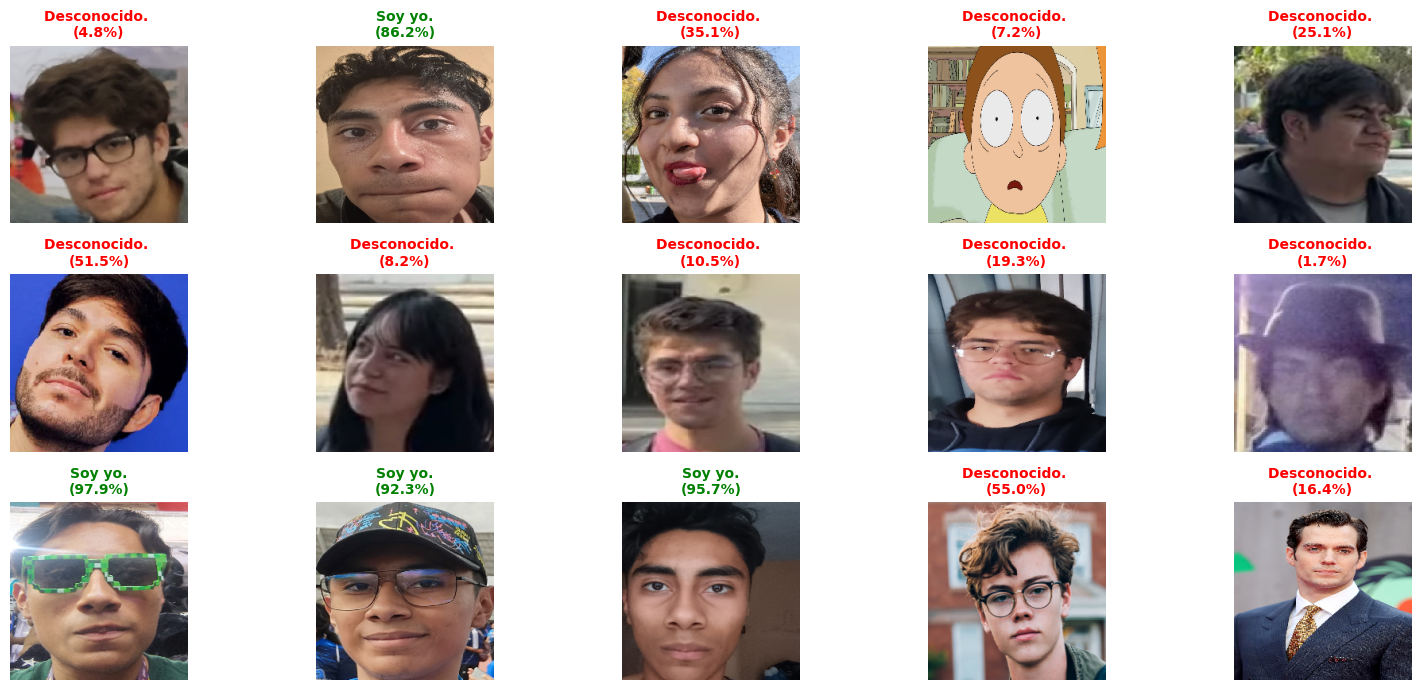

In [6]:
# Evaluamos.
generar_grid_evaluacion(lista_imgs)